# MNIST Classification with scikit-learn `MLPClassifier`
## Student Version

In this exercise, you will build a fully connected neural network classifier for handwritten digits.

Complete the cells marked **TODO**.

Expected folder structure:

```text
your_notebook_folder/
│
├── MNIST_MLPClassifier_Student.ipynb
└── MNIST_Data/
    ├── x_train.npy
    ├── y_train.npy
    ├── x_test.npy
    └── y_test.npy
```


## Step 0: Import libraries


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, log_loss

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


daoru


## Step 1: Load and normalize the MNIST data

Keep the labels as integer class IDs rather than one-hot encoded vectors.


In [2]:
mnist_path = "./MNIST_Data/"

# Load training images.
train_data = np.load(mnist_path + "x_train.npy").astype(np.float32)

# TODO 1:
# Normalize pixel values from [0,255] to approximately [0,1].
train_data = train_data / 255

# TODO 2:
# Reshape training images to (number_of_images, 28, 28, 1).
train_data = train_data.reshape(train_data.shape[0], 28, 28, 1)

# TODO 3:
# Load the training labels, reshape them to 1D, and convert them to integers.
train_labels = np.load(mnist_path + "y_train.npy").reshape(-1).astype(np.int64)

# Load test images.
test_data = np.load(mnist_path + "x_test.npy").astype(np.float32)

# TODO 4:
# Apply the same normalization and reshape to the test images.
test_data = test_data / 255
test_data = test_data.reshape(test_data.shape[0], 28, 28, 1)

# TODO 5:
# Load the test labels as a 1D integer array.
test_labels = np.load(mnist_path + "y_test.npy").reshape(-1).astype(np.int64)

class_names = [str(i) for i in range(10)]

print("Training data shape:", train_data.shape)
print("Training labels shape:", train_labels.shape)
print("Test data shape:", test_data.shape)
print("Test labels shape:", test_labels.shape)


Training data shape: (60000, 28, 28, 1)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28, 1)
Test labels shape: (10000,)


## Step 2: Visualize sample images


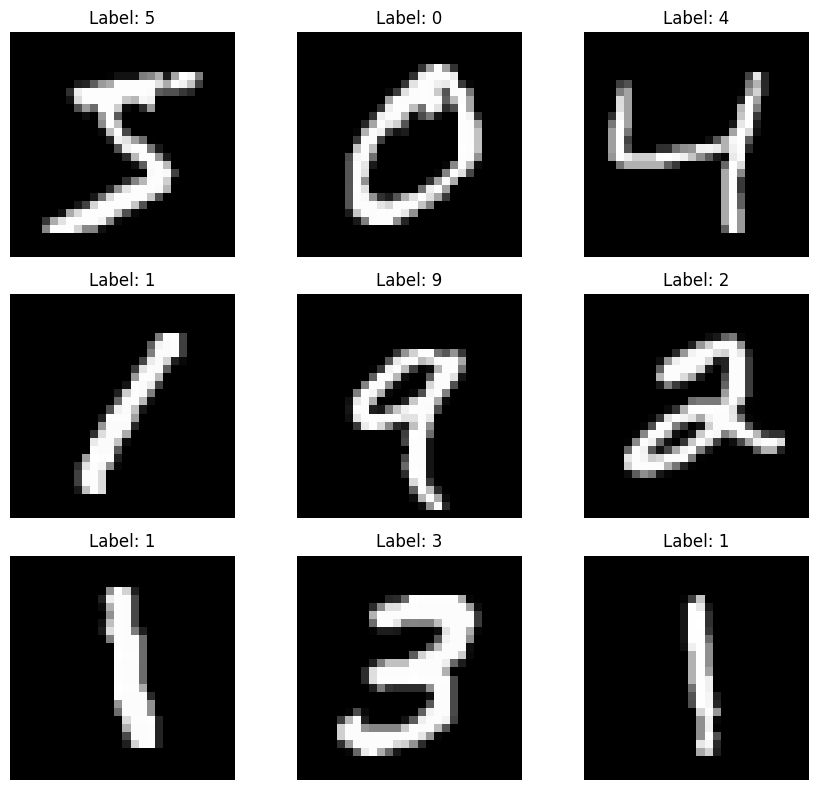

In [3]:
plt.figure(figsize=(9, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    # Remove the channel dimension.
    image = train_data[i].squeeze()

    # TODO 6:
    # Reverse the shift so the values are suitable for display.
    display_image = image

    plt.imshow(display_image, cmap="gray")
    plt.title(f"Label: {train_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## Step 3: Flatten each image

Convert each `(28, 28, 1)` image into 784 input features.


In [4]:
image_shape = train_data.shape[1:]

# TODO 7:
X_train_full = train_data.reshape(train_data.shape[0], 784)
X_test = test_data.reshape(test_data.shape[0], 784)

y_train_full = train_labels
y_test = test_labels

print("Training feature matrix:", X_train_full.shape)
print("Test feature matrix:", X_test.shape)


Training feature matrix: (60000, 784)
Test feature matrix: (10000, 784)


## Step 4: Create a validation set

Use 20% of the original training data for validation.


In [5]:
# TODO 8:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train_full
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Training: (48000, 784)
Validation: (12000, 784)
Test: (10000, 784)


## Step 5: Build the neural network

Use:

- one hidden layer,
- 128 hidden neurons,
- ReLU,
- Adam,
- batch size 64,
- learning rate 0.001,
- early stopping.


In [6]:
# TODO 9:
model = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    batch_size=64,
    learning_rate_init=0.001,
    max_iter=30,
    shuffle=True,
    random_state=RANDOM_STATE,
    verbose=True,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=5
)


## Step 6: Train the model


In [7]:
# TODO 10:
model.fit(X_train, y_train)

print("Completed epochs:", model.n_iter_)
print("Final training loss:", model.loss_)


Iteration 1, loss = 0.35306303
Validation score: 0.940000
Iteration 2, loss = 0.16693278
Validation score: 0.957500
Iteration 3, loss = 0.11717143
Validation score: 0.967500
Iteration 4, loss = 0.08905570
Validation score: 0.970000
Iteration 5, loss = 0.06939157
Validation score: 0.974375
Iteration 6, loss = 0.05608916
Validation score: 0.975625
Iteration 7, loss = 0.04467872
Validation score: 0.970000
Iteration 8, loss = 0.03741670
Validation score: 0.975833
Iteration 9, loss = 0.03052279
Validation score: 0.976875
Iteration 10, loss = 0.02546824
Validation score: 0.976458
Iteration 11, loss = 0.02137597
Validation score: 0.978958
Iteration 12, loss = 0.01710736
Validation score: 0.979167
Iteration 13, loss = 0.01455804
Validation score: 0.977500
Iteration 14, loss = 0.01273984
Validation score: 0.978333
Iteration 15, loss = 0.01088329
Validation score: 0.978542
Iteration 16, loss = 0.01011024
Validation score: 0.976250
Iteration 17, loss = 0.01014879
Validation score: 0.978333
Iterat

## Step 7: Plot training loss


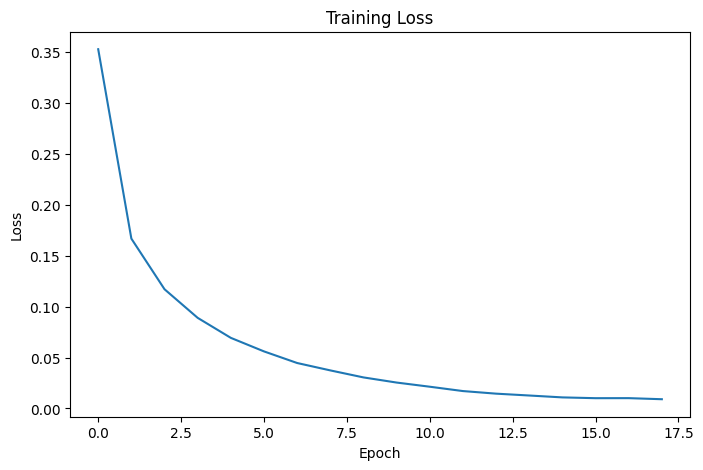

In [8]:
# TODO 11:
plt.figure(figsize=(8, 5))

plt.plot(model.loss_curve_)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()


## Step 8: Evaluate on the validation set


In [9]:
# TODO 12:
y_val_pred = model.predict(X_val)
y_val_prob = model.predict_proba(X_val)

val_accuracy = accuracy_score(y_val, y_val_pred)
val_loss = log_loss(y_val, y_val_prob, labels=model.classes_)

print(f"Validation accuracy: {val_accuracy:.4f}")
print(f"Validation log loss: {val_loss:.4f}")


Validation accuracy: 0.9760
Validation log loss: 0.0878


## Step 9: Evaluate on the test set


In [10]:
# TODO 13:
y_test_pred = model.predict(X_test)
y_test_prob = model.predict_proba(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_loss = log_loss(y_test, y_test_prob, labels=model.classes_)

print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test log loss: {test_loss:.4f}")


Test accuracy: 0.9759
Test log loss: 0.0783


### Classification report


In [11]:
# TODO 14:
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=class_names,
        digits=4
    )
)


              precision    recall  f1-score   support

           0     0.9806    0.9796    0.9801       980
           1     0.9885    0.9877    0.9881      1135
           2     0.9702    0.9777    0.9739      1032
           3     0.9743    0.9752    0.9748      1010
           4     0.9796    0.9756    0.9776       982
           5     0.9831    0.9753    0.9792       892
           6     0.9791    0.9781    0.9786       958
           7     0.9774    0.9669    0.9721      1028
           8     0.9548    0.9764    0.9655       974
           9     0.9711    0.9653    0.9682      1009

    accuracy                         0.9759     10000
   macro avg     0.9759    0.9758    0.9758     10000
weighted avg     0.9760    0.9759    0.9759     10000



## Step 10: Prediction demo


In [16]:
def predict_sample(idx):
    flat_sample = X_test[idx].reshape(1,-1)

    # TODO 15:
    # Predict probabilities for this single sample.
    probabilities = model.predict_proba(flat_sample)[0]

    # TODO 16:
    # Find the predicted digit.
    predicted_class = np.argmax(probabilities)

    true_class = y_test[idx]

    normalized_image = flat_sample.reshape(image_shape).squeeze()

    # TODO 17:
    # Reverse the normalization shift for display.
    display_image = normalized_image

    confidence = np.max(probabilities)

    plt.figure(figsize=(4, 4))
    plt.imshow(display_image, cmap="gray")
    plt.axis("off")
    plt.title(
        f"True: {true_class}\n"
        f"Predicted: {predicted_class}\n"
        f"Confidence: {confidence:.2f}"
    )
    plt.show()


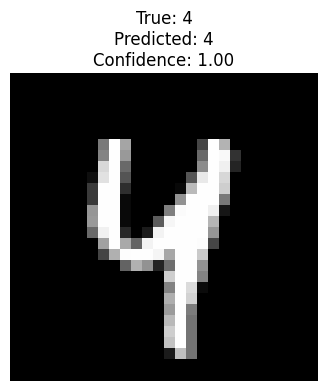

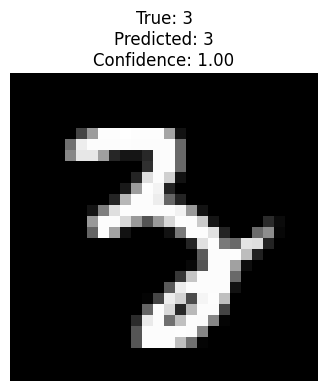

In [17]:
predict_sample(42)
predict_sample(87)


## Discussion questions

1. Why is MNIST easier for an FNN to classify than CIFAR-10?
2. Why does each MNIST image produce 784 input features?
3. Why do we flatten the image before using `MLPClassifier`?
4. Why are labels not one-hot encoded here?
5. What does `hidden_layer_sizes=(128,)` mean?
6. What does `predict_proba()` return?
7. What is the role of the validation set?
8. What does `early_stopping=True` do?
9. What would high training accuracy but lower validation accuracy suggest?
10. Why might CNNs become more useful for more complicated image datasets?
